In [5]:
# Assignment 3
# Unsupervised Learning using K-Means Clustering

import os

# Limit CPU threads to avoid K-Means warning on Windows
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [6]:
data = {
    "Annual_Income": [
        15, 18, 20, 25, 30,
        35, 40, 45, 50, 55,
        60, 65, 70, 75, 80,
        85, 90, 95, 100, 105
    ],

    "Spending_Score": [
        20, 25, 22, 30, 35,
        80, 75, 85, 78, 82,
        40, 45, 42, 50, 48,
        90, 88, 92, 95, 91
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

Dataset:
    Annual_Income  Spending_Score
0              15              20
1              18              25
2              20              22
3              25              30
4              30              35
5              35              80
6              40              75
7              45              85
8              50              78
9              55              82
10             60              40
11             65              45
12             70              42
13             75              50
14             80              48
15             85              90
16             90              88
17             95              92
18            100              95
19            105              91


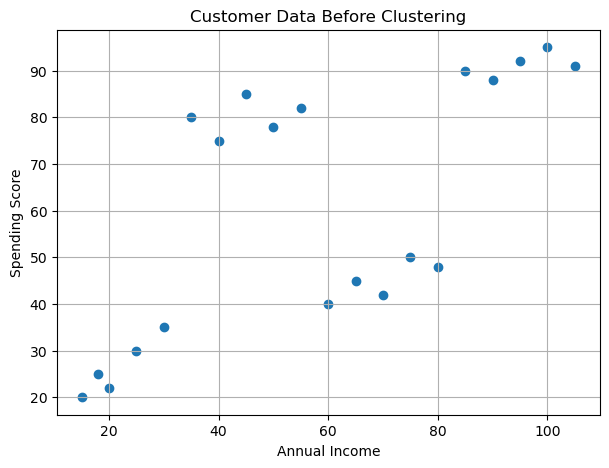

In [7]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data Before Clustering")

plt.grid()
plt.show()

In [8]:
# Select features
X = df[["Annual_Income", "Spending_Score"]]

# Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train the model and get cluster labels
df["Cluster"] = kmeans.fit_predict(X)

print("K-Means model trained successfully!")

print("\nData with Cluster Labels:")
print(df)

K-Means model trained successfully!

Data with Cluster Labels:
    Annual_Income  Spending_Score  Cluster
0              15              20        0
1              18              25        0
2              20              22        0
3              25              30        0
4              30              35        0
5              35              80        1
6              40              75        1
7              45              85        1
8              50              78        1
9              55              82        1
10             60              40        1
11             65              45        1
12             70              42        1
13             75              50        1
14             80              48        1
15             85              90        2
16             90              88        2
17             95              92        2
18            100              95        2
19            105              91        2


C:\Users\Akarsh Mehrotra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
centers = kmeans.cluster_centers_

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[21.6 26.4]
 [57.5 62.5]
 [95.  91.2]]


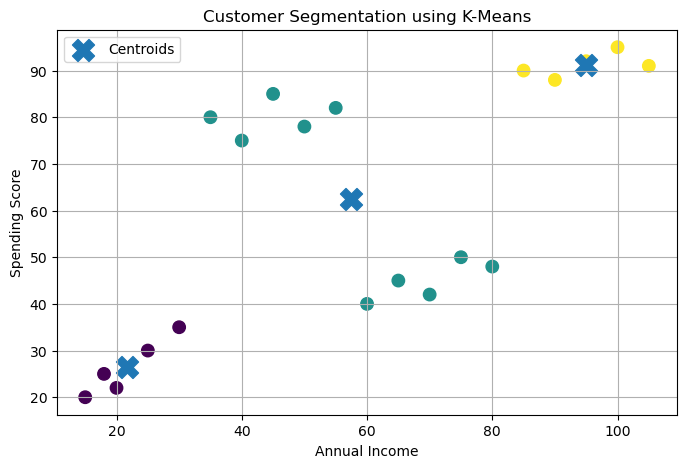

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=80
)

# Plot cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.legend()
plt.grid()

plt.show()

In [11]:
print("Number of Customers in Each Cluster:")
print(df["Cluster"].value_counts().sort_index())

Number of Customers in Each Cluster:
Cluster
0     5
1    10
2     5
Name: count, dtype: int64


In [12]:
for cluster in sorted(df["Cluster"].unique()):

    print("\nCluster", cluster)
    
    print(
        df[df["Cluster"] == cluster][
            ["Annual_Income", "Spending_Score"]
        ]
    )


Cluster 0
   Annual_Income  Spending_Score
0             15              20
1             18              25
2             20              22
3             25              30
4             30              35

Cluster 1
    Annual_Income  Spending_Score
5              35              80
6              40              75
7              45              85
8              50              78
9              55              82
10             60              40
11             65              45
12             70              42
13             75              50
14             80              48

Cluster 2
    Annual_Income  Spending_Score
15             85              90
16             90              88
17             95              92
18            100              95
19            105              91


C:\Users\Akarsh Mehrotra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Akarsh Mehrotra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Akarsh Mehrotra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Akarsh Mehrotra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans 

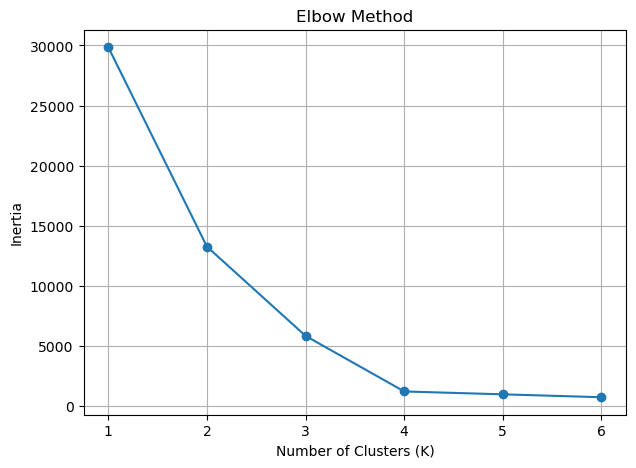

In [13]:
inertia = []

K = range(1, 7)

for k in K:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X)
    
    inertia.append(model.inertia_)

plt.figure(figsize=(7, 5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid()
plt.show()